In [3]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries loaded ✅")

Libraries loaded ✅


In [4]:
# Mount your Google Drive so Colab can access files stored there
from google.colab import drive
drive.mount('/content/drive')

# Then load the file directly from your Drive instead of uploading
# Upload the Excel file to your Drive once, then point to it like this
df = pd.read_excel('/content/drive/MyDrive/nhs_rtt_data/WLMDS-Summary-to-22-Feb-2026.xlsx',
                   skiprows=13,
                   header=None)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [11]:
df.to_csv('/content/drive/MyDrive/nhs_rtt_data/nhs_rtt_clean.csv', index=False)

In [34]:
# Save the cleaned dataframe as a CSV file
df.to_csv('nhs_rtt_clean.csv', index=False)

# Save to computer
from google.colab import files
files.download('nhs_rtt_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
#  first 20 rows to find where the real data starts
for i, row in df.iterrows():
    print(f"Row {i}:", row.values[:6])  # just first 6 columns
    if i > 20:
        break

Row 0: [nan nan 'Number of acute providers submitting'
 'Total number of providers submitting' 'Total Waiting List'
 'Up to 18 weeks']
Row 1: [nan '2021-09-19 00:00:00' '136' '333' '5370227' '3487589']
Row 2: [nan '2021-09-26 00:00:00' '138' '361' '5540982' '3578280']
Row 3: [nan '2021-10-03 00:00:00' '135' '360' '5593220' '3601680']
Row 4: [nan '2021-10-10 00:00:00' '134' '353' '5453547' '3549616']
Row 5: [nan '2021-10-17 00:00:00' '136' '330' '5588639' '3614395']
Row 6: [nan '2021-10-24 00:00:00' '132' '335' '5309240' '3430170']
Row 7: [nan '2021-10-31 00:00:00' '136' '354' '5579362' '3586371']
Row 8: [nan '2021-11-07 00:00:00' '134' '352' '5516443' '3533463']
Row 9: [nan '2021-11-14 00:00:00' '135' '351' '5649161' '3602483']
Row 10: [nan '2021-11-21 00:00:00' '136' '329' '5677412' '3598109']
Row 11: [nan '2021-11-28 00:00:00' '135' '341' '5600911' '3553747']
Row 12: [nan '2021-12-05 00:00:00' '136' '370' '5686885' '3598251']
Row 13: [nan '2021-12-12 00:00:00' '134' '346' '5678862' '

In [14]:
# skiprows=13 jumps straight to where the actual numbers begin.
df = pd.read_excel(
    '/content/drive/MyDrive/nhs_rtt_data/WLMDS-Summary-to-22-Feb-2026.xlsx',
    skiprows=13,
    header=None
)

# assign column names
df.columns = [
    "drop",                          # empty first column
    "week_ending",                   # date of the week
    "acute_providers",               # number of acute trusts submitting data
    "total_providers",               # all provider types submitting
    "total_waiting_list",            # total people on the waiting list
    "within_18w",                    # waiting up to 18 weeks
    "18_to_26w",                     # waiting 18–26 weeks
    "26_to_40w",                     # waiting 26–40 weeks
    "40_to_52w",                     # waiting 40–52 weeks
    "52_to_65w",                     # waiting 52–65 weeks (breaching target)
    "65_to_78w",                     # waiting 65–78 weeks
    "78_to_104w",                    # waiting 78–104 weeks
    "over_104w",                     # waiting over 2 years
    "unknown_clock_start",           # pathways with no known start date
    "pct_within_18w",                # % seen within 18 weeks (key NHS target)
    "pct_over_52w",                  # % waiting over 52 weeks
    "first_attend_within_18w",       # first outpatient appointment within 18w
    "first_attend_total",            # total waiting for first appointment
    "pct_first_attend_within_18w",   # % of first attendances within 18w
    "new_rtt_acute",                 # acute providers submitting new RTT periods
    "new_rtt_total_providers",       # all providers submitting new RTT
    "new_rtt_total",                 # total new RTT pathways started
    "completed_acute",               # acute providers with completed pathways
    "completed_total_providers",     # all providers with completed pathways
    "completed_total",               # total completed pathways
    "admitted_rtt",                  # completed — admitted (had treatment)
    "non_admitted_rtt"               # completed — non-admitted (discharged/other)
]

# Drop the empty first column
df = df.drop(columns=["drop"])

# Show first 5 rows
df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,week_ending,acute_providers,total_providers,total_waiting_list,within_18w,18_to_26w,26_to_40w,40_to_52w,52_to_65w,65_to_78w,...,first_attend_total,pct_first_attend_within_18w,new_rtt_acute,new_rtt_total_providers,new_rtt_total,completed_acute,completed_total_providers,completed_total,admitted_rtt,non_admitted_rtt
0,NaN,Number of acute providers submitting,Total number of providers submitting,Total Waiting List,Up to 18 weeks,Over 18 and up to 26 weeks,Over 26 and up to 40 weeks,Over 40 and up to 52 weeks,Over 52 and up to 65 weeks,Over 65 and up to 78 weeks,...,Waiting for first attendance,% waiting for first attendance within 18w,Number of acute providers submitting,Total number of providers submitting,Total,Number of acute providers submitting,Total number of providers submitting,Total,Admitted - RTT,Non-Admitted - RTT
1,2021-09-19 00:00:00,136,333,5370227,3487589,701301,585740,293604,127904,36758,...,-,-,131,255,361493,111,229,235136,51923,183213
2,2021-09-26 00:00:00,138,361,5540982,3578280,735212,610901,301995,135307,38199,...,-,-,133,277,371951,111,230,232637,51033,181604
3,2021-10-03 00:00:00,135,360,5593220,3601680,769923,613305,291848,139574,39778,...,-,-,132,274,364078,110,228,235199,52026,183173
4,2021-10-10 00:00:00,134,353,5453547,3549616,739286,603761,261875,137359,40662,...,-,-,131,268,359996,108,225,242666,54704,187962


In [15]:
# Drop row 0 (leftover header) and reset the index
df = df.drop(index=0).reset_index(drop=True)

#  show all the junk rows
mask = pd.to_datetime(df["week_ending"], errors="coerce").isna()
print(df[mask]["week_ending"].values)

[nan nan
 'Including estimates for missing data and data quality issues at NHS Acute providers'
 nan nan 'W-E 22/02/2026 data quality and coverage'
 'The NHS acute provider/s listed below did not submit RTT incomplete pathway data or submitted data affected by data quality issues.'
 'Adjusting to include the latest available total waiting list position for the provider/s listed below suggests the total waiting list figure for this latest week could be 7,200,504.'
 nan nan 'Organisation Code' 'RHQ' nan
 "* The main source for '% within 18 weeks' and '% > 52 weeks' is the monthly Accredited Official Statistics on RTT waiting times (https://www.england.nhs.uk/statistics/statistical-work-areas/rtt-waiting-times/). "]


In [16]:
# Remove any rows where week_ending can't be parsed as a real date
df = df[pd.to_datetime(df["week_ending"], errors="coerce").notna()].reset_index(drop=True)

# convert to datetime
df["week_ending"] = pd.to_datetime(df["week_ending"])

# Confirm the shape
print("Clean shape:", df.shape)
print("Date range:", df["week_ending"].min(), "→", df["week_ending"].max())

Clean shape: (233, 26)
Date range: 2021-09-19 00:00:00 → 2026-02-22 00:00:00


In [17]:
# List of all columns that should contain numbers
numeric_cols = [
    "acute_providers", "total_providers", "total_waiting_list",
    "within_18w", "18_to_26w", "26_to_40w", "40_to_52w",
    "52_to_65w", "65_to_78w", "78_to_104w", "over_104w",
    "unknown_clock_start", "pct_within_18w", "pct_over_52w",
    "first_attend_within_18w", "first_attend_total",
    "new_rtt_acute", "new_rtt_total_providers", "new_rtt_total",
    "completed_acute", "completed_total_providers", "completed_total",
    "admitted_rtt", "non_admitted_rtt"
]

# Convert each column to a number
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check how many missing values per column
print(df.isnull().sum())

week_ending                     0
acute_providers                 1
total_providers                 1
total_waiting_list              0
within_18w                      0
18_to_26w                       0
26_to_40w                       0
40_to_52w                       0
52_to_65w                       0
65_to_78w                       0
78_to_104w                      0
over_104w                       0
unknown_clock_start             0
pct_within_18w                  1
pct_over_52w                    1
first_attend_within_18w        81
first_attend_total             81
pct_first_attend_within_18w     1
new_rtt_acute                   1
new_rtt_total_providers         1
new_rtt_total                   1
completed_acute                 1
completed_total_providers       1
completed_total                 1
admitted_rtt                    1
non_admitted_rtt                1
dtype: int64


In [18]:
# Statistical summary of key columns
df[["total_waiting_list", "within_18w", "over_104w",
    "pct_within_18w", "pct_over_52w"]].describe().round(2)

,total_waiting_list,within_18w,over_104w,pct_within_18w,pct_over_52w
count,233.00,233.00,233.00,232.00,232.00
mean,7038913.84,4149044.29,3399.88,0.59,0.04
std,619138.74,275991.57,6567.01,0.02,0.01
min,5309240.00,3390071.00,73.00,0.56,0.02
25%,6792354.00,3972941.00,131.00,0.58,0.03
50%,7299814.00,4289051.00,302.00,0.59,0.05
75%,7476141.00,4358133.00,2260.00,0.61,0.05
max,7684148.00,4466114.00,25519.00,0.65,0.06


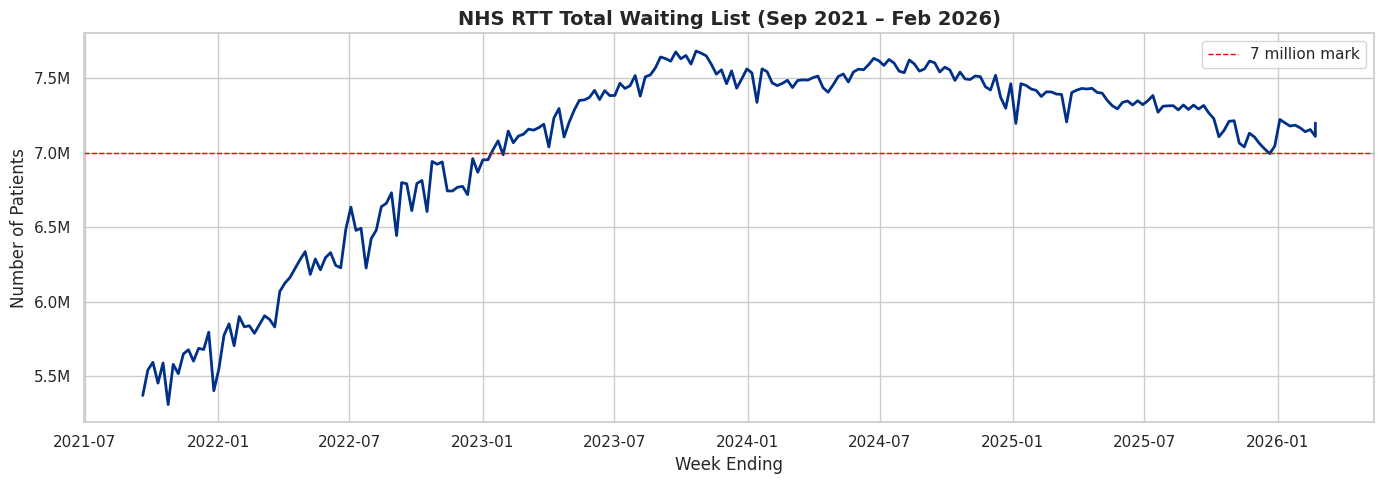

In [19]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(14, 5))

# Plot week_ending on x-axis, total waiting list on y-axis
ax.plot(df["week_ending"], df["total_waiting_list"],
        color="#003087", linewidth=2)

# A red dashed line at 7 million as a reference point
ax.axhline(7_000_000, color="red", linestyle="--",
           linewidth=1, label="7 million mark")

# Labels and title
ax.set_title("NHS RTT Total Waiting List (Sep 2021 – Feb 2026)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Week Ending")
ax.set_ylabel("Number of Patients")

# Format y-axis to show millions instead of raw numbers
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

ax.legend()
plt.tight_layout()
plt.show()

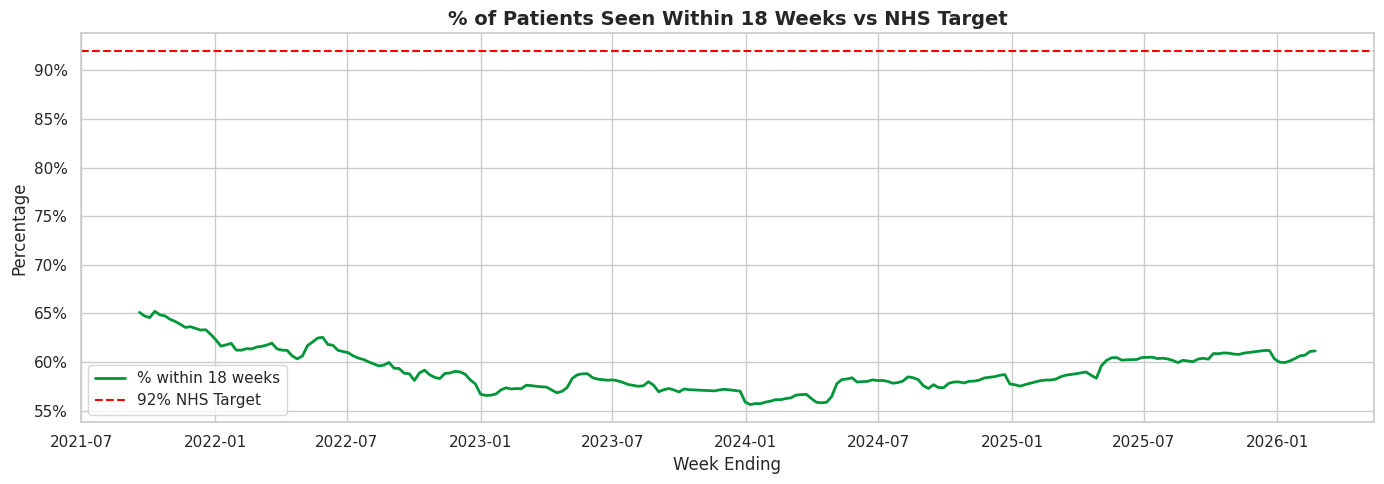

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))

# Plot the actual % within 18 weeks each week
ax.plot(df["week_ending"], df["pct_within_18w"],
        color="#009639", linewidth=2, label="% within 18 weeks")

# NHS target line at 92% this shows how far below target the system is.
ax.axhline(0.92, color="red", linestyle="--",
           linewidth=1.5, label="92% NHS Target")

ax.set_title("% of Patients Seen Within 18 Weeks vs NHS Target",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Week Ending")
ax.set_ylabel("Percentage")

# Format y-axis as percentage (0.65 → 65%)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
)

ax.legend()
plt.tight_layout()
plt.show()

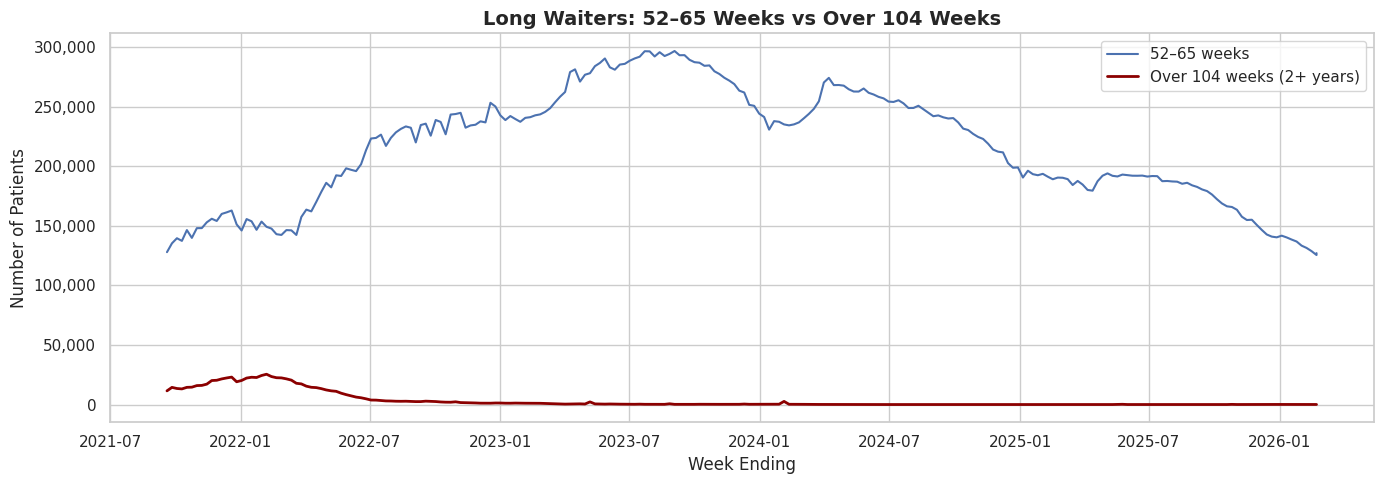

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

# Two lines one for over 52 weeks, one for over 104 weeks
# The most politically sensitive figures in NHS performance
ax.plot(df["week_ending"], df["52_to_65w"],
        label="52–65 weeks", linewidth=1.5)
ax.plot(df["week_ending"], df["over_104w"],
        color="darkred", linewidth=2, label="Over 104 weeks (2+ years)")

ax.set_title("Long Waiters: 52–65 Weeks vs Over 104 Weeks",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Week Ending")
ax.set_ylabel("Number of Patients")

# Format y-axis with comma separators (e.g. 25,000)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

ax.legend()
plt.tight_layout()
plt.show()

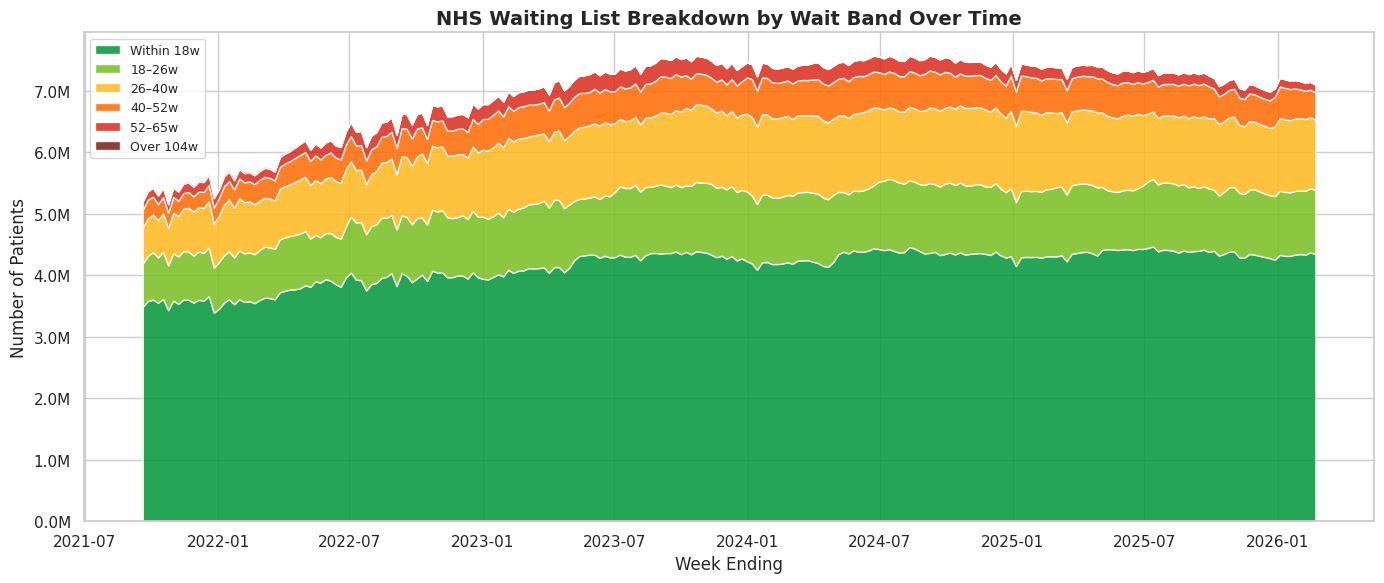

In [22]:
# Stacked area chart shows how the MIX of wait times has changed

wait_bands = ["within_18w", "18_to_26w", "26_to_40w",
              "40_to_52w", "52_to_65w", "over_104w"]

labels = ["Within 18w", "18–26w", "26–40w",
          "40–52w", "52–65w", "Over 104w"]

colors = ["#009639", "#78BE20", "#FFB81C",
          "#FF6900", "#DA291C", "#7B1C1C"]

fig, ax = plt.subplots(figsize=(14, 6))

# stackplot stacks each band on top of the previous one
ax.stackplot(df["week_ending"],
             [df[col] for col in wait_bands],
             labels=labels, colors=colors, alpha=0.85)

ax.set_title("NHS Waiting List Breakdown by Wait Band Over Time",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Week Ending")
ax.set_ylabel("Number of Patients")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

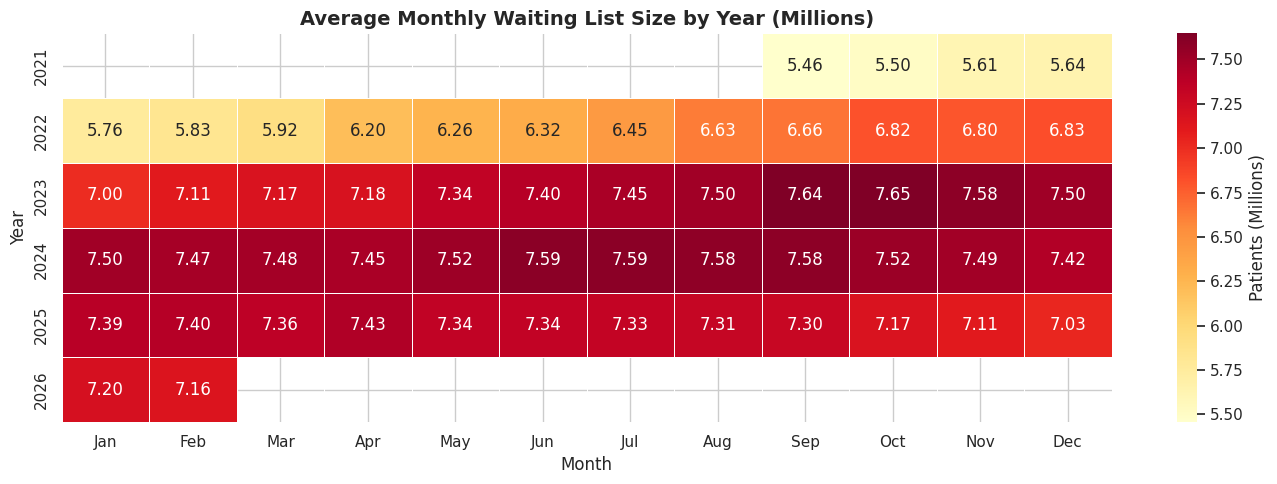

In [23]:
# Extract month and year to pivot the data into a grid
df["month"] = df["week_ending"].dt.month
df["month_name"] = df["week_ending"].dt.strftime("%b")
df["year"] = df["week_ending"].dt.year

# Group by year and month, rows=year, columns=month
heatmap_data = df.groupby(["year", "month"])["total_waiting_list"].mean()
heatmap_pivot = heatmap_data.unstack(level="month")

# Rename columns from numbers to month abbreviations
heatmap_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 5))

# sns.heatmap colours each cell by value — darker = higher waiting list
sns.heatmap(heatmap_pivot / 1_000_000,  # divide to show in millions
            annot=True,                  # show the number inside each cell
            fmt=".2f",                   # 2 decimal places
            cmap="YlOrRd",              # yellow → orange → red colour scale
            linewidths=0.5,
            ax=ax,
            cbar_kws={"label": "Patients (Millions)"})

ax.set_title("Average Monthly Waiting List Size by Year (Millions)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()

In [24]:
# Check missing values in key columns before modelling
print(df[["week_ending", "total_waiting_list",
          "within_18w", "over_104w",
          "pct_within_18w"]].isnull().sum())

week_ending           0
total_waiting_list    0
within_18w            0
over_104w             0
pct_within_18w        1
dtype: int64


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df["days_since_start"] = (df["week_ending"] - df["week_ending"].min()).dt.days

X = df[["days_since_start", "within_18w", "over_104w", "pct_within_18w"]]
y = df["total_waiting_list"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")

Training rows: 186, Test rows: 47


In [26]:
# Create the model LinearRegression to find the best straight line
model = LinearRegression()

# Drops rows with NaN values from X and y before splitting
data_for_model = df[["days_since_start", "within_18w", "over_104w", "pct_within_18w", "total_waiting_list"]].dropna()

X = data_for_model[["days_since_start", "within_18w", "over_104w", "pct_within_18w"]]
y = data_for_model["total_waiting_list"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:,.0f} patients")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 14,968 patients
R² Score: 0.9991


In [27]:
# See which features the model relied on most
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print(coefficients)

            Feature   Coefficient
1        within_18w  1.669529e+00
2         over_104w  1.601485e+00
0  days_since_start -1.224593e+01
3    pct_within_18w -1.137885e+07


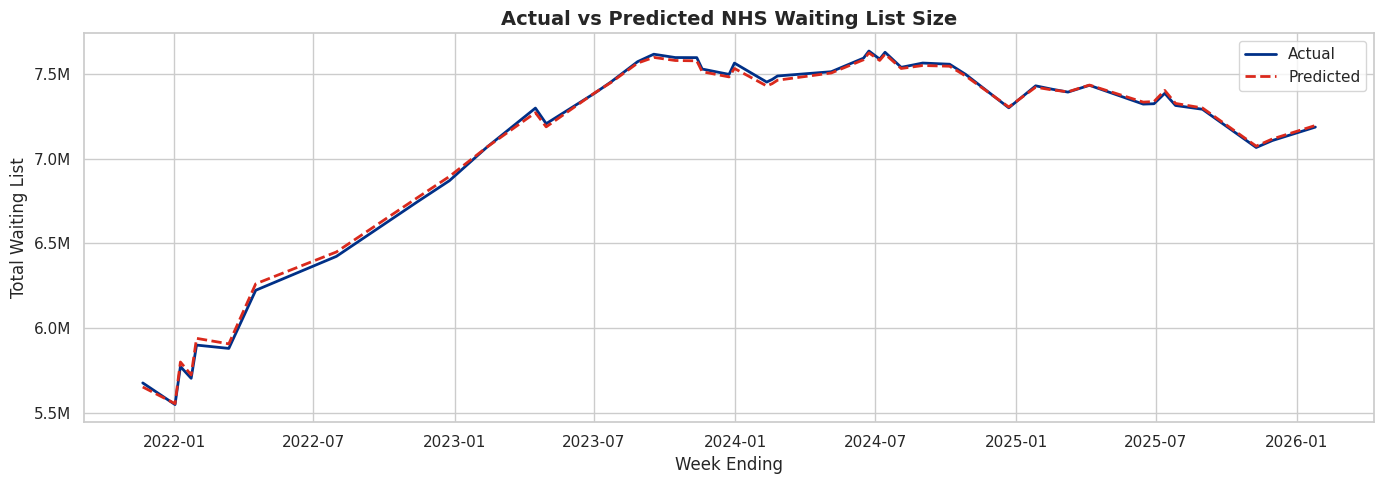

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))

test_dates = df.loc[X_test.index, "week_ending"].sort_values()
actual_sorted = y_test.loc[test_dates.index]
pred_sorted = pd.Series(y_pred, index=X_test.index).loc[test_dates.index]

ax.plot(test_dates, actual_sorted,
        label="Actual", color="#003087", linewidth=2)
ax.plot(test_dates, pred_sorted,
        label="Predicted", color="#DA291C",
        linewidth=2, linestyle="--")

ax.set_title("Actual vs Predicted NHS Waiting List Size",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Week Ending")
ax.set_ylabel("Total Waiting List")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# Rebuild test_dates and predictions cleanly
test_df = df.loc[X_test.index, ["week_ending"]].copy()
test_df["actual"] = y_test.values
test_df["predicted"] = y_pred
test_df = test_df.sort_values("week_ending")

print(test_df.head())
print("Date range:", test_df["week_ending"].min(), "→", test_df["week_ending"].max())

   week_ending   actual     predicted
9   2021-11-21  5677412  5.653384e+06
15  2022-01-02  5549749  5.555242e+06
16  2022-01-09  5773932  5.800738e+06
18  2022-01-23  5704610  5.724539e+06
19  2022-01-30  5900584  5.940318e+06
Date range: 2021-11-21 00:00:00 → 2026-01-25 00:00:00


In [30]:
# Install library to build the HTML report
!pip install plotly --quiet

# plotly for creating interactive dashboard charts
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

print("Plotly loaded ✅")

Plotly loaded ✅


In [31]:
# Create a dashboard with 4 charts arranged in a 2x2 grid
# rows=2, cols=2 means 2 rows and 2 columns of charts
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Total Waiting List Over Time",
        "% Seen Within 18 Weeks vs 92% Target",
        "Long Waiters (52w+ and 104w+)",
        "Actual vs Predicted Waiting List"
    )
)

# Chart 1: Total Waiting List
fig.add_trace(
    go.Scatter(x=df["week_ending"], y=df["total_waiting_list"],
               mode="lines", name="Total Waiting List",
               line=dict(color="#003087", width=2)),
    row=1, col=1
)

# Chart 2: % Within 18 Weeks
fig.add_trace(
    go.Scatter(x=df["week_ending"], y=df["pct_within_18w"],
               mode="lines", name="% Within 18w",
               line=dict(color="#009639", width=2)),
    row=1, col=2
)
# Add the 92% target line
fig.add_hline(y=0.92, line_dash="dash", line_color="red",
              annotation_text="92% Target", row=1, col=2)

# Chart 3: Long Waiters
fig.add_trace(
    go.Scatter(x=df["week_ending"], y=df["52_to_65w"],
               mode="lines", name="52–65 weeks",
               line=dict(color="#FF6900", width=2)),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=df["week_ending"], y=df["over_104w"],
               mode="lines", name="Over 104 weeks",
               line=dict(color="darkred", width=2)),
    row=2, col=1
)

# Chart 4: Actual vs Predicted
fig.add_trace(
    go.Scatter(x=test_dates, y=actual_sorted,
               mode="lines", name="Actual",
               line=dict(color="#003087", width=2)),
    row=2, col=2
)
fig.add_trace(
    go.Scatter(x=test_dates, y=pred_sorted,
               mode="lines", name="Predicted",
               line=dict(color="#DA291C", width=2, dash="dash")),
    row=2, col=2
)

# Layout
fig.update_layout(
    title_text="NHS RTT Waiting Time Analysis Dashboard",
    title_font=dict(size=20),
    height=700,
    showlegend=True,
    template="plotly_white"
)

fig.show()

In [32]:
# Save the dashboard as a single HTML file
fig.write_html("nhs_rtt_dashboard.html")
print("Dashboard saved ✅")

Dashboard saved ✅


In [33]:
# Download file
from google.colab import files
files.download("nhs_rtt_dashboard.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>